In [27]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, ConcatDataset, Dataset
import matplotlib.pyplot as plt
import numpy as np
from csv2numpy import prepTimeSeqData

In [ ]:
def xplot(x_pairs_1): 
    x_plot = x_pairs_1.detach().cpu().numpy() if isinstance(x_pairs_1, torch.Tensor) else x_pairs_1
    n_plots = x_plot.shape[1]
    fig, axes = plt.subplots(n_plots, 1, figsize=(8, 2 * max(1, n_plots)), sharex=True)
    if n_plots == 1:
        axes = [axes]
    for j, ax in enumerate(axes):
        for k in range(x_plot.shape[2]):
            ax.plot(x_plot[:, j, k], label=f"k={k}")
        ax.set_title(f"pair index {j}")
        ax.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

class TimeSeriesConv(nn.Module):
    """
    time-conv and feature processing without the transformer 
    TO DO: try combining stage 3A and 3B into a single conv processing stream without groups.
    """

    def __init__(self, dim_in, dim_out, dim_u=1, time_len=256, group_size=7, num_groups=7, tuple_size=2, numGrpUnpaired=2):
        super().__init__()

        # time conv properties
        # These should all be kept smaller than time_len
        K1 = 2
        K2 = 4
        K3 = 8

        # preprocessing features -------------------------------------------
        
        C1 = 32

        self.num_groups = num_groups
        self.group_size = group_size
        self.numGrpUnpaired = numGrpUnpaired
        self.tuple_size = tuple_size
        self.num_pairs = (num_groups - numGrpUnpaired) * group_size  
        used_for_pairing = self.num_pairs * tuple_size
        leftover_dim = dim_in - used_for_pairing - (numGrpUnpaired * group_size)
        self.pair_output = tuple_size

        # Stage 1: pairwise linear 
        self.pair_fc1 = nn.Linear(tuple_size, C1) 
        self.pair_fc2 = nn.Linear(C1, self.pair_output) 

        # Stage 2: linear over flattened group
        self.group_fcA = nn.Linear(group_size * self.pair_output, 32)
        self.group_fcC = nn.Linear(group_size, 16)
        self.group_fcB = nn.Linear((num_groups-numGrpUnpaired) * self.pair_output + numGrpUnpaired, 16)
        mlp_in = ((num_groups-numGrpUnpaired) * 32) + (group_size * 16) + (numGrpUnpaired * 16) + leftover_dim
        dim_model = mlp_in

        # stage 3A: time-only processing to get to len_model
        self.time_conv1 = nn.Conv1d(mlp_in, mlp_in, groups=mlp_in, kernel_size=K1)
        self.time_conv2 = nn.Conv1d(mlp_in, mlp_in, groups=mlp_in, kernel_size=K2)
        self.time_conv3 = nn.Conv1d(mlp_in, mlp_in, groups=mlp_in, kernel_size=K3)
        self.time_fc = nn.Linear(time_len - K1 - K2 - K3 + 3, 1)
        #self.time_fc = nn.Linear(time_len - K1 - K2 + 2, len_model)
        #self.time_fc = nn.Linear(time_len - K1 + 1, len_model)

        # stage 3B: feature-only processing to get to dim_model
        """
        self.fc1 = nn.Linear(mlp_in, 256)
        #self.fc2 = nn.Linear(256, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 64)
        self.fc5 = nn.Linear(64, dim_model)
        """
        #self.fc1 = nn.Linear(mlp_in, dim_model)

        # ---------------------------------------------------------------------------------------

        # MLP latent dynamics 
        self.fc2 = nn.Linear(dim_model + dim_u, 256)
        #self.fc3 = nn.Linear(256, 256)
        #self.fc4 = nn.Linear(256, 256)
        self.fc5 = nn.Linear(256, dim_model)

        # Output head for next-step prediction ------------------------------------------------
        self.fco1 = nn.Linear(dim_model, 128)
        #self.fco2 = nn.Linear(64, 64)
        #self.fco3 = nn.Linear(64, 64)
        #self.fco4 = nn.Linear(128, dim_out)
        self.fcoAmp = nn.Linear(128, (num_groups-numGrpUnpaired)*group_size) # for predicting amplitude of each feature
        self.fcoFreq = nn.Linear(128, (num_groups-numGrpUnpaired)*group_size) # for predicting inst frequency of each feature
        self.fcoUnpaired = nn.Linear(128, numGrpUnpaired*group_size) # for predicting unpaired features directly

    def forward(self, x, u_seq):
        """
        x: (B, T, dim_in)
        B) "Threads" = within channels, across freq bands 
        A) "Groups" = within freq bands, across channels
        """
        if x.ndim != 3:
            raise ValueError(f"Expected input ndim=3, got {x.ndim}")
        T = x.size(1)
        B = x.size(0)
        rollout = u_seq.size(1)

        num_paired = (self.num_pairs * self.tuple_size) # "kN1"
        num_unpaired = self.numGrpUnpaired * self.group_size # "N2"
        x_used = x[:, :, :num_paired]  # (B,T,kN1)
        x_unpaired = x[:, :, num_paired:(num_paired+num_unpaired)] # (B,T,N2)
        x_left = x[:, :, (num_paired+num_unpaired):]  # (B,T,n); may be unused
        # for skip connection at output:
        xAmp_skip = x_used[:,-1:,:self.num_pairs]
        xCos_skip = x_used[:,-1:,self.num_pairs:2*self.num_pairs]
        xSin_skip = x_used[:,-1:,2*self.num_pairs:3*self.num_pairs]
        xUnpaired_skip = x_unpaired[:,-1:,:]
        """
        x_pairs = torch.stack( 
            (
                x_used[:, :, :self.num_pairs],            # first half
                x_used[:, :, self.num_pairs:],            # second half
            ),
            dim=3
        )  # (B,T,N,2)
        """
        x_pairs = x_used.view(x_used.shape[0], x_used.shape[1], self.tuple_size, -1).permute(0,1,3,2).contiguous() # (B,T,N1,k)
        x_unpaired_groups = x_unpaired.view(x_unpaired.shape[0], x_unpaired.shape[1], self.numGrpUnpaired, -1) 
        x_unpaired_threads = x_unpaired.view(x_unpaired.shape[0], x_unpaired.shape[1], -1, self.group_size).permute(0,1,3,2).contiguous()

        print(x_pairs.shape)
        plotidx = 1
        x_pairs_1 = x_pairs[plotidx]
        x_unpaired_groups_1 = x_unpaired_groups[plotidx]
        x_unpaired_threads_1 = x_unpaired_threads[plotidx]
        xplot(x_pairs_1)

        # Stage 1
        """
        p = F.gelu(self.pair_fc1(x_pairs))     # (B,T,N,C1)
        p = F.gelu(self.pair_fc2(p))           # (B,T,N,pair_output)
        """
        p = x_pairs

        # Stage 2A: groups
        p_groups = p.view(B, T, self.num_groups-self.numGrpUnpaired, self.group_size * self.pair_output)  # (B,T,num_groups,...)
        print(p_groups.shape)
        xplot(p_groups[plotidx])
        a = F.gelu(self.group_fcA(p_groups))                      
        a_flat = a.view(B, T, -1)                                 
        c = F.gelu(self.group_fcC(x_unpaired_groups))
        c_flat = c.view(B, T, -1)                               

        # Stage 2B: threads
        p_threads = p.view(B, T, self.num_groups-self.numGrpUnpaired, self.group_size, self.pair_output)   
        p_threads = p_threads.permute(0,1,3,2,4).contiguous()           
        p_threads = p_threads.view(B, T, self.group_size, -1)            # (B,T,group_size,...)
        print(p_threads.shape)
        xplot(p_threads[plotidx])
        print(x_unpaired_threads.shape)
        xplot(x_unpaired_threads[plotidx])
        p_threads = torch.cat([p_threads, x_unpaired_threads], dim=-1) 
        print(p_threads.shape)
        xplot(p_threads[plotidx])
        b = F.gelu(self.group_fcB(p_threads))                         
        b_flat = b.view(B, T, -1)         
        h = torch.cat([a_flat, b_flat, c_flat, x_left], dim=-1)        # (B,T,mlp_in)

        # Stage 3A time processing
        h = h.permute(0,2,1) # (B, dim_model, T)
        h = F.gelu(self.time_conv1(h))
        h = F.gelu(self.time_conv2(h))
        h = F.gelu(self.time_conv3(h))
        h = F.gelu(self.time_fc(h))
        h = h.permute(0,2,1) # (B, T, dim_model)

        # Stage 3B MLP
        #h = F.gelu(self.fc1(h))
        #h = F.gelu(self.fc2(h))
        #h = F.gelu(self.fc3(h))
        #h = F.gelu(self.fc4(h))
        #h = F.gelu(self.fc5(h))

        # Transformer --------------------------------------------------------------------

        # latent dynamics 
        z = h[:, -1, :]  # (B, dim_model)
        #zskip = z.clone()
        #Z = torch.zeros(z.size(0), rollout, z.size(1), device=z.device) 
        Z_list = []
        for r in range(rollout):
            u = u_seq[:, r, :] # (B, dim_u)
            z = torch.cat([z, u], dim=1) # (B, dim_model+dim_u)
            z = F.gelu(self.fc2(z))
            #z = F.gelu(self.fc3(z))
            #z = F.gelu(self.fc4(z))
            z = F.gelu(self.fc5(z))
            #z = z + zskip # skip connection
            #zskip = z.clone()
            #Z[:, r, :] = z
            Z_list.append(z)
        Z = torch.stack(Z_list, dim=1)

        # Output head --------------------------------------------------------------------
        #R = torch.arange(rollout).float().unsqueeze(0).unsqueeze(2) + 1 # (1, rollout, 1) why is this needed when rollout uses skip connections?
        y = F.gelu(self.fco1(Z))
        #y = F.gelu(self.fco2(y))
        #y = F.gelu(self.fco3(y))
        #y = self.fco4(y)  # (B, dim_out)
        #out = y + xy_skip # skip connection
        yAmp = torch.cumsum(self.fcoAmp(y), dim=1) + xAmp_skip # predict amplitude with skip connection
        yFreq = torch.cumsum(self.fcoFreq(y), dim=1)
        yCos = xCos_skip*torch.cos(yFreq) - xSin_skip*torch.sin(yFreq) # reconstruct cosine with predicted freq and skip connection
        ySin = xSin_skip*torch.cos(yFreq) + xCos_skip*torch.sin(yFreq) # reconstruct sine with predicted freq and skip connection
        yUnpaired = self.fcoUnpaired(y) + xUnpaired_skip # predict unpaired features with skip connection
        out = torch.cat([yAmp, yCos, ySin, yUnpaired], dim=2) # (B, rollout, ...)
        return out



Sampling frequency (Hz): 1000.0
Baseline outliers: 0 of 511
Data outliers: 0 of 511
Baseline Pairs created: 31
Input shape : (31, 32, 22)
Output shape: (31, 16, 22)
Event shape: (31, 16, 1)
Main Pairs created: 31
Input shape : (31, 32, 22)
Output shape: (31, 16, 22)
Event shape: (31, 16, 1)
torch.Size([16, 32, 22]) torch.Size([16, 16, 1])
torch.Size([16, 32, 6, 3])


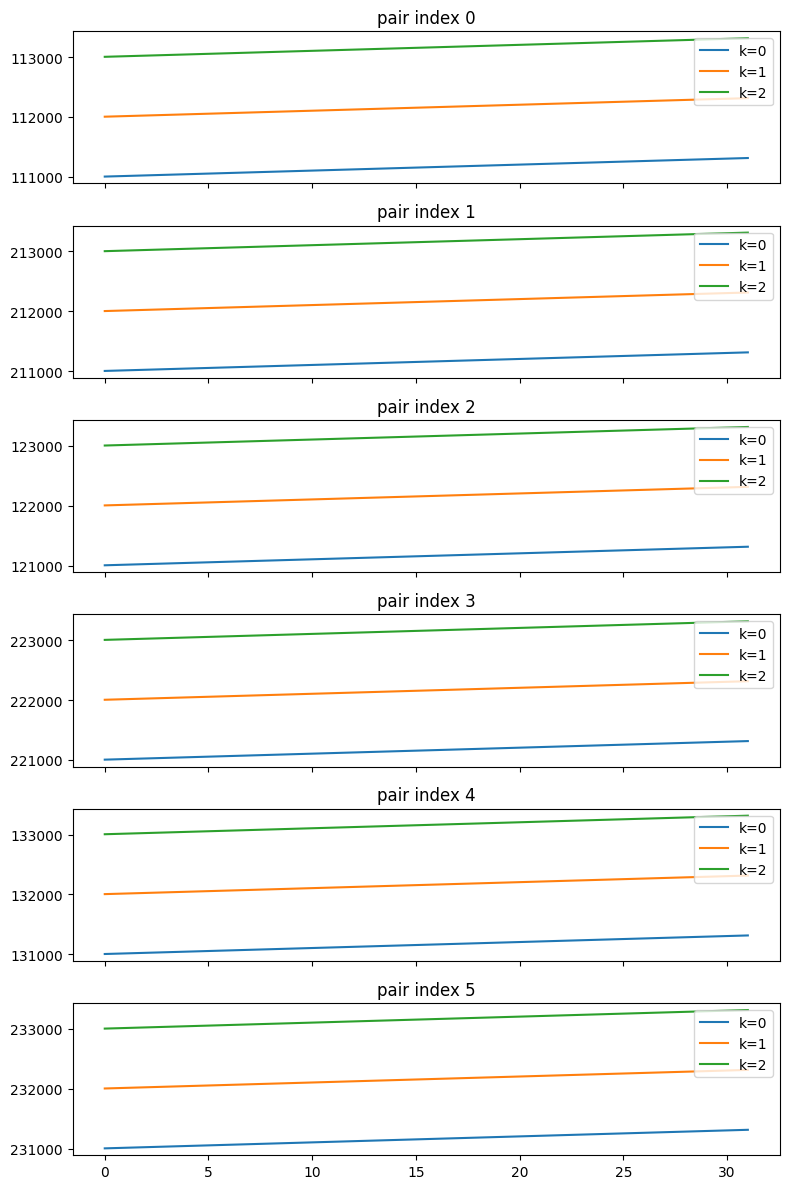

torch.Size([16, 32, 3, 6])


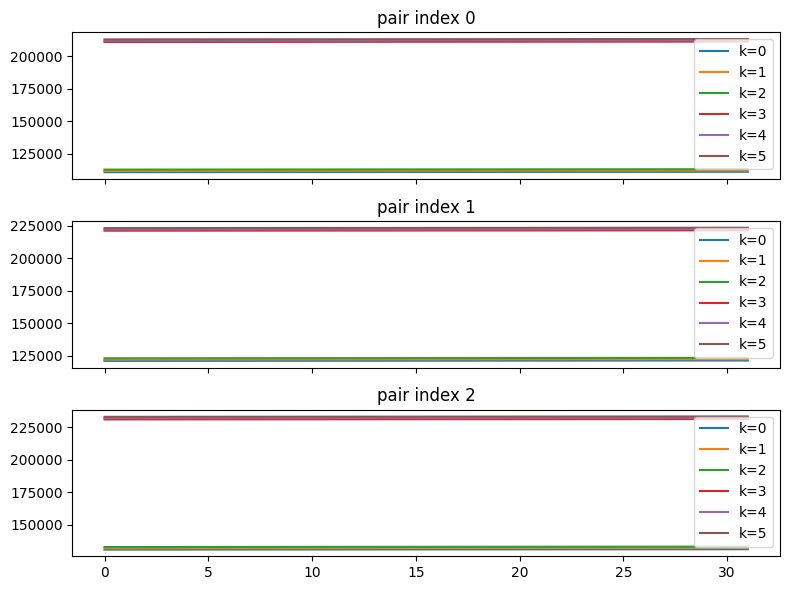

torch.Size([16, 32, 2, 9])


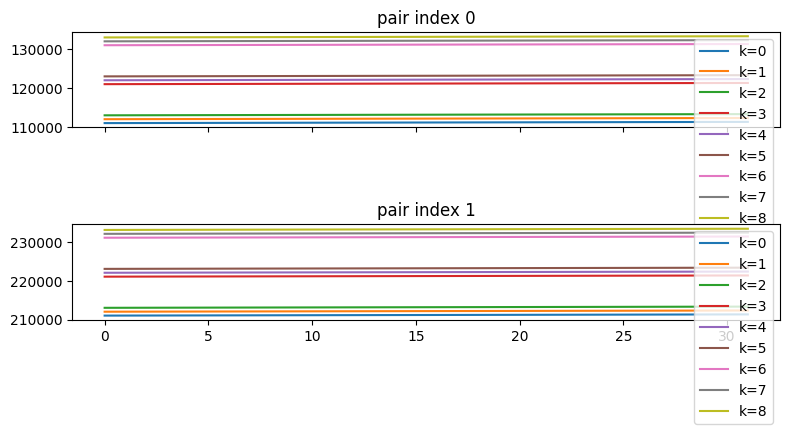

torch.Size([16, 32, 2, 2])


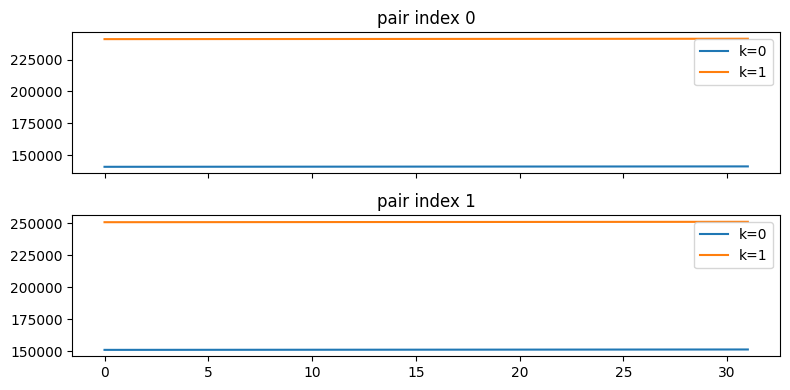

torch.Size([16, 32, 2, 11])


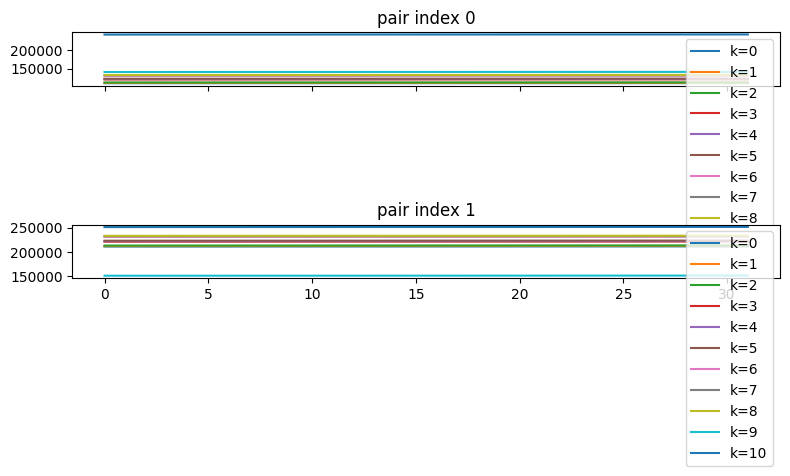

In [29]:
# %%
# Prepare the Data ---------------------------------------------------------------------

seq_len = 32  # sequence length
mdl_Ts = 0.01  # model sample time, s
hzn_len = 16 # samples

fs, feature_names, feature_correction, Xs, Ys, X, Y, _, _, _, _, Us, U = prepTimeSeqData(
    seq_len=seq_len, maxNumel=1e9, hzn_len=hzn_len, dt_target=mdl_Ts, 
    filepath="")
Xs = torch.from_numpy(Xs).float()
Ys = torch.from_numpy(Ys).float()
Us = torch.from_numpy(Us).float()
X = torch.from_numpy(X).float()
Y = torch.from_numpy(Y).float()
U = torch.from_numpy(U).float()

num_feat = len(feature_names)

# %%
# Initialize the Model, Loss Function, and Optimizer

test_size=0.5
batch_size = 16

groupsize = 2

model = TimeSeriesConv(dim_in=num_feat, dim_out=num_feat, time_len=seq_len, group_size=groupsize, num_groups=5, numGrpUnpaired=2, tuple_size=3)

train_N = int((1 - test_size) * len(X))
X_train = X[:train_N]
Y_train = Y[:train_N]
U_train = U[:train_N]
X_test = X[train_N:]
Y_test = Y[train_N:]
U_test = U[train_N:]

train_dataset = TensorDataset(X_train, Y_train, U_train)
test_dataset = TensorDataset(X_test, Y_test, U_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

model.eval()
print(X_test.shape, U_test.shape)
Ypred = model(X_test, U_test)